# MedGemma Fine-tune Prototype (OMAMA Balanced Set)

This copy of the notebook is wired to our balanced `test_balanced` dataset.
Steps:
1. Load images + metadata from scratch and wrap them into a Hugging Face dataset.
2. Format prompts that include metadata context.
3. Runs the training section 


In [19]:
import os
from pathlib import Path
import json
import random

from dotenv import load_dotenv
import numpy as np
from datasets import Dataset, DatasetDict, Features, ClassLabel, Value, Image
from PIL import Image as PILImage

In [20]:
# Load .env so HF_TOKEN and other secrets are available
ENV_PATH = Path("/home/a.kanamarlapudi001/projects/ml_cv_projects/Experiments/.env")
load_dotenv(dotenv_path=ENV_PATH)
HF_TOKEN = os.environ.get("HF_TOKEN")


In [21]:
SCRATCH_ROOT = Path("/hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma")
BALANCED_DIR = SCRATCH_ROOT / "test_balanced"
IMAGES_DIR = BALANCED_DIR / "images"
META_DIR = BALANCED_DIR / "metadata"

if not IMAGES_DIR.exists():
    raise FileNotFoundError(f"Images not found at {IMAGES_DIR}")
if not META_DIR.exists():
    raise FileNotFoundError(f"Metadata not found at {META_DIR}")

print(f"Images directory: {IMAGES_DIR}")
print(f"Metadata directory: {META_DIR}")


Images directory: /hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma/test_balanced/images
Metadata directory: /hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma/test_balanced/metadata


In [22]:
npz_files = sorted(IMAGES_DIR.glob("*.npz"))
print(f"Found {len(npz_files):,} balanced samples")
if not npz_files:
    raise RuntimeError("No npz files found; check path")


Found 11,606 balanced samples


In [23]:
def load_npz(path: Path) -> np.ndarray:
    with np.load(path, mmap_mode="r") as data:
        arr = data["data"].astype(np.float32)
    return arr


def load_metadata(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)


def to_uint8_pil(arr: np.ndarray) -> PILImage:
    if arr.dtype != np.uint8:
        min_val, max_val = arr.min(), arr.max()
        arr = (arr - min_val) / max(1e-6, (max_val - min_val))
        arr = (arr * 255.0).round().astype(np.uint8)
    return PILImage.fromarray(arr, mode="L")


In [24]:
records = []
for path in npz_files:
    meta_path = META_DIR / f"{path.stem}.json"
    if not meta_path.exists():
        continue
    meta = load_metadata(meta_path)
    label = meta["label"]
    image = to_uint8_pil(load_npz(path))
    records.append({
        "image": image,
        "metadata": meta,
        "label": label,
    })

print(f"Prepared {len(records):,} records")
assert records, "No records collected"


/tmp/ipykernel_228519/1017694537.py:17: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return PILImage.fromarray(arr, mode="L")


Prepared 11,606 records


In [25]:
labels = sorted({rec["label"] for rec in records})
CLASS_NAMES = labels
label2id = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print("Class names:", CLASS_NAMES)


Class names: ['IndexCancer', 'NonCancer']


In [ ]:
def metadata_to_text(meta: dict) -> str:
    view = meta.get("View", "unknown view")
    laterality = meta.get("ImageLaterality", "?")
    spacing = meta.get("ImagerPixelSpacing", [None, None])
    spacing_str = f"{spacing[0]} mm" if spacing and spacing[0] else "unknown"
    presets = meta.get("WindowCenterWidthExplanation", [])
    presets_str = "/".join(presets) if presets else "none"
    score = meta.get("score", None)
    coords = meta.get("coords", None)
    bbox_str = f"bbox at {coords} (score {score:.2f})" if coords and score is not None else "no bbox"
    patient = meta.get("PatientID", "")
    return (
        f"Patient {patient}. View: {view} ({laterality}). Pixel spacing {spacing_str}. "
        f"Window presets: {presets_str}. {bbox_str}."
    )


In [27]:
hf_features = Features({
    "image": Image(decode=True),
    "label": ClassLabel(names=CLASS_NAMES),
    "metadata_text": Value("string"),
    "metadata": Value("string"),
})


In [28]:
def build_dataset(split_ratio: float = 0.8) -> DatasetDict:
    random.shuffle(records)
    split_index = int(len(records) * split_ratio)
    train_records = records[:split_index]
    val_records = records[split_index:]

    def convert(rec_list):
        images = [rec["image"] for rec in rec_list]
        labels = [label2id[rec["label"]] for rec in rec_list]
        meta_texts = [metadata_to_text(rec["metadata"]) for rec in rec_list]
        raw_meta = [json.dumps(rec["metadata"]) for rec in rec_list]
        return Dataset.from_dict({
            "image": images,
            "label": labels,
            "metadata_text": meta_texts,
            "metadata": raw_meta,
        }, features=hf_features)

    return DatasetDict({
        "train": convert(train_records),
        "validation": convert(val_records)
    })

data = build_dataset()
print(data)


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'metadata_text', 'metadata'],
        num_rows: 9284
    })
    validation: Dataset({
        features: ['image', 'label', 'metadata_text', 'metadata'],
        num_rows: 2322
    })
})


Label: NonCancer
Metadata text:
 Patient DH58VU9PIX71. View: cranio-caudal (R). Pixel spacing 0.09409090909091 mm. Window presets: NORMAL/HARDER/SOFTER. bbox at [352, 260, 404, 320] (score 0.60).


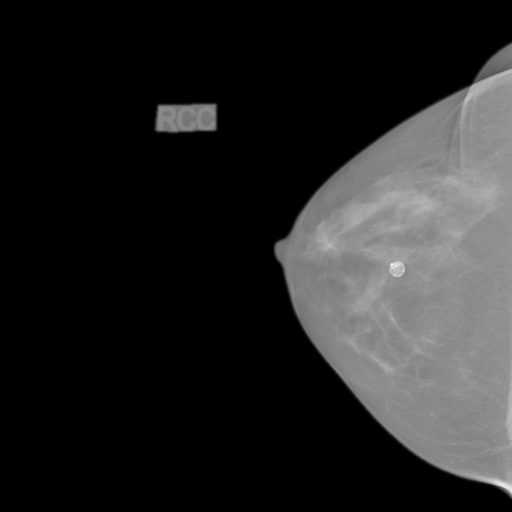

In [29]:
sample = data["train"][0]
print("Label:", CLASS_NAMES[sample["label"]])
print("Metadata text:\n", sample["metadata_text"])
sample["image"]


In [30]:
from typing import Any

TISSUE_CLASSES = [f"{chr(ord('A') + idx)}: {name}" for idx, name in enumerate(CLASS_NAMES)]
options = "\n".join(TISSUE_CLASSES)

PROMPT_TEMPLATE = (
    "You are classifying a mammogram. \n"
    "{meta_text}\n"
    "Choose the most appropriate label:\n"
    f"{options}"
)

def format_data(example: dict[str, Any]) -> dict[str, Any]:
    prompt = PROMPT_TEMPLATE.format(meta_text=example["metadata_text"])
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": TISSUE_CLASSES[example["label"]],
                },
            ],
        },
    ]
    return example

data = data.map(format_data, remove_columns=["metadata", "metadata_text"])
print(data["train"][0]["messages"])


Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 2322/2322 [00:00<00:00, 5451.41 examples/s]

[{'content': [{'text': None, 'type': 'image'}, {'text': 'You are classifying a mammogram. \nPatient DH58VU9PIX71. View: cranio-caudal (R). Pixel spacing 0.09409090909091 mm. Window presets: NORMAL/HARDER/SOFTER. bbox at [352, 260, 404, 320] (score 0.60).\nChoose the most appropriate label:\nA: IndexCancer\nB: NonCancer', 'type': 'text'}], 'role': 'user'}, {'content': [{'text': 'B: NonCancer', 'type': 'text'}], 'role': 'assistant'}]


In [31]:
# The original CRC dataset loader has been removed.
# `data` is already built from the OMAMA balanced set above.

In [32]:
# Preview handled earlier; remove redundant cell

In [33]:
# Label preview already shown above


In [34]:
# Legacy prompt template removed; current `format_data` defined above uses OMAMA metadata.

In [35]:
# Mapping to messages already done above; skip duplicate call.

##  Fine-tuning setup

The cells below are unchanged from the original MedGemma demo. Once the data cells above run without issues, you can execute this section to fine-tune the model. Update cache paths, output directories, and HF token before running.


In [36]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from huggingface_hub import login

model_id = "google/medgemma-4b-it"

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN not set. Add it to Experiments/.env as HF_TOKEN=...")

login(token=HF_TOKEN)

if torch.cuda.get_device_capability()[0] < 8:
    raise ValueError("GPU does not support bfloat16; please run on Ampere/Hopper class GPU.")

model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    cache_dir=str(SCRATCH_ROOT / "hf_cache"),
    token=HF_TOKEN,
)

model_kwargs["quantization_config"] = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=model_kwargs["torch_dtype"],
    bnb_4bit_quant_storage=model_kwargs["torch_dtype"],
)

model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)
processor.tokenizer.padding_side = "right"

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:11<00:00,  5.82s/it]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [37]:
from peft import LoraConfig

peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=16,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

In [38]:
from typing import Any


def collate_fn(examples: list[dict[str, Any]]):
    texts = []
    images = []
    for example in examples:
        images.append([example["image"].convert("RGB")])
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    # Tokenize the texts and process the images
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # The labels are the input_ids, with the padding and image tokens masked in
    # the loss computation
    labels = batch["input_ids"].clone()

    # Mask image tokens
    image_token_id = [
        processor.tokenizer.convert_tokens_to_ids(
            processor.tokenizer.special_tokens_map["boi_token"]
        )
    ]
    # Mask tokens that are not used in the loss computation
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == image_token_id] = -100
    labels[labels == 262144] = -100

    batch["labels"] = labels
    return batch

In [39]:
from trl import SFTConfig

num_train_epochs = 1
learning_rate = 2e-4

args = SFTConfig(
    output_dir=str(SCRATCH_ROOT / "runs" / "medgemma_balanced_lora"),
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=50,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=50,
    learning_rate=learning_rate,
    bf16=True,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="linear",
    push_to_hub=False,
    report_to="tensorboard",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    label_names=["labels"],
)

In [41]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=data["train"],
    eval_dataset=data["validation"].shuffle().select(range(200)),  # Use subset of validation set for faster run
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

trainer.train()

/home/a.kanamarlapudi001/miniconda3/envs/medgemma-bal/lib/python3.10/site-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/a.kanamarlapudi001/miniconda3/envs/medgemma-bal/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,6.345500,0.551867,0.332166,304355.000000,0.849822
100,2.111700,0.518671,0.506066,608805.000000,0.856666
150,2.062000,0.509848,0.437330,912815.000000,0.859024
200,2.034100,0.506135,0.369995,1217084.000000,0.859114
250,2.011800,0.504175,0.421348,1521338.000000,0.859446
300,2.009400,0.500588,0.409992,1825440.000000,0.860788
350,1.998300,0.496322,0.368163,2129410.000000,0.862488
400,1.986200,0.495443,0.391468,2433591.000000,0.860692
450,1.971700,0.493167,0.363407,2737849.000000,0.862044
500,1.968400,0.491095,0.325588,3042126.000000,0.862692


TrainOutput(global_step=581, training_loss=2.3796280616326917, metrics={'train_runtime': 10282.5943, 'train_samples_per_second': 0.903, 'train_steps_per_second': 0.057, 'total_flos': 9.254979463664563e+16, 'train_loss': 2.3796280616326917, 'entropy': 0.34244919032597343, 'num_tokens': 3530485.0, 'mean_token_accuracy': 0.8633553503958646, 'epoch': 1.0})

In [42]:
full_metrics = trainer.evaluate(data["validation"])
print(full_metrics)

{'eval_loss': 0.4900454878807068, 'eval_runtime': 717.2611, 'eval_samples_per_second': 3.237, 'eval_steps_per_second': 0.81, 'eval_entropy': 0.35028080832014397, 'eval_num_tokens': 3530485.0, 'eval_mean_token_accuracy': 0.8624551880995706, 'epoch': 1.0}


In [ ]:

SAVE_DIR = "/hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma/hf_proc_messages_metadata"
data.save_to_disk(SAVE_DIR)
print("Saved dataset to:", SAVE_DIR)

 ... (more hidden) ...
 ... (more hidden) ...

Saved dataset to: /hpcstor6/scratch01/a/a.kanamarlapudi001/med-gemma/hf_proc_messages_metadata


In [45]:
# Placeholder from original notebook removed
!nvidia-smi

Fri Nov  7 18:47:19 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:47:00.0 Off |                    0 |
| N/A   26C    P0              60W / 400W |  36657MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
